# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

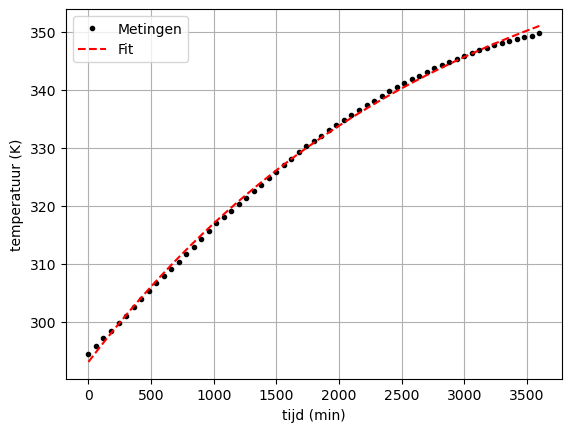

1813.019479


In [4]:
import numpy as np
data = np.loadtxt("tempmetingen.csv",skiprows=1,delimiter=';')

time = data[:, 0]*60 # tijd in seconden
temp = data[:, 1]+273.15 # temperatuur in Kelvin

m_maatbeker = 820.8e-3 # in kilogram
m_maatbeker_water_i = 1292.9e-3 # in kilogram
m_maatbeker_water_e = 1274.9e-3 # in Kilogram

def func(t, T_inf, T_0, k):
    return T_inf - (T_inf - T_0) * np.exp(-k * t)

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Initial guesses voor parameters
p0 = [350, 294.15, 0.01]  # T_inf, T_0, k
popt, pcov = curve_fit(func, time, temp, p0=p0)

x_fit = np.linspace(np.min(time), np.max(time), 1000)
y_fit = func(x_fit, popt[0], popt[1], popt[2])
plt.figure()
plt.plot(time, temp, "k.", label='Metingen')
plt.plot(x_fit, y_fit, 'r--', label='Fit')
plt.xlabel('tijd (min)')
plt.ylabel('temperatuur (K)')
plt.legend()
plt.grid(True)
plt.show()

verdampingswarmte_w=2256 # in kiloJoules per kilogram
m_verdamptewater=m_maatbeker_water_i-m_maatbeker_water_e-m_maatbeker # in kilogram
E_verloren=abs(verdampingswarmte_w*m_verdamptewater) # kiloJoules
# ik neem hierbij aan dat water wat is verdampt niet bij het water dat is verwarmt hoort
c_water=4.19 # kilojoules per kilogram
m_water_niet_verdampt=m_maatbeker_water_e-m_maatbeker # Kilogram
E_verwarming_water=c_water*m_water_niet_verdampt # Kilojoules
E_totaal=E_verloren+E_verwarming_water
print(E_totaal) 

## om dit experiment beter te maken